In [2]:
import os
import tensorflow as tf
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Import Keras phục vụ huấn luyện
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tv_C_model import build_model_v1, build_model_v2
from tensorflow.keras.callbacks import  ModelCheckpoint

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [6]:
# 1. Đọc dữ liệu từ thư mục 'data/' của Thành viên B
images = np.load("images.npy")
labels = np.load("labels.npy")
class_names = np.load("class_names.npy")

print(f"Tổng số mẫu ảnh: {images.shape[0]}")

# 2. One-hot encoding nhãn
num_classes = len(class_names)
X_temp, X_test, y_temp, y_test = train_test_split(
    images, labels, test_size=0.15, random_state=42, stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat   = to_categorical(y_val, num_classes=num_classes)
y_test_cat  = to_categorical(y_test, num_classes=num_classes)

# Bước 3.2: Từ 85% còn lại, tách tiếp ra tập Train (70% tổng) và Validation (15% tổng)
# Tỷ lệ tách tập Val từ tập Temp: 15 / 85 ≈ 0.1765
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)
print(f"Tập Train: {X_train.shape} | Tập Validation: {X_val.shape} | Tập Test: {X_test.shape}")

Tổng số mẫu ảnh: 400
Tập Train: (279, 4096) | Tập Validation: (61, 4096) | Tập Test: (60, 4096)


In [7]:

# Tạo thư mục 'models/' nếu chưa có để chuẩn bị lưu file
os.makedirs("models", exist_ok=True)
def make_callbacks(model_path):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),
        ModelCheckpoint(
            filepath=model_path,
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]

# MODEL V1 (ReLU)
print("\n>>> BẮT ĐẦU HUẤN LUYỆN MODEL V1 (ReLU)...")
model_v1 = build_model_v1(
    input_shape=(images.shape[1],),
    num_classes=num_classes
)
history_v1 = model_v1.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=make_callbacks("models/model_v1_relu.h5"),
    verbose=1
)
model_v1.save("models/model_v1_relu.h5")


# MODEL V2 (Sigmoid) 
print("\n>>> BẮT ĐẦU HUẤN LUYỆN MODEL V2 (Sigmoid)...")
model_v2 = build_model_v2(
    input_shape=(images.shape[1],),
    num_classes=num_classes
)

history_v2 = model_v2.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=make_callbacks("models/model_v2_sigmoid.h5"),
    verbose=1
)

# Lưu lại model tốt nhất sau khi restore_best_weights
model_v2.save("models/model_v2_sigmoid.h5")



>>> BẮT ĐẦU HUẤN LUYỆN MODEL V1 (ReLU)...
Epoch 1/50
1/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2812 - loss: 1.4097
Epoch 1: val_loss improved from None to 1.48933, saving model to models/model_v1_relu.h5



Epoch 1: finished saving model to models/model_v1_relu.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.2366 - loss: 1.8314 - val_accuracy: 0.3115 - val_loss: 1.4893
Epoch 2/50
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4062 - loss: 1.4052
Epoch 2: val_loss improved from 1.48933 to 1.28251, saving model to models/model_v1_relu.h5



Epoch 2: finished saving model to models/model_v1_relu.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3692 - loss: 1.4731 - val_accuracy: 0.4262 - val_loss: 1.2825
Epoch 3/50
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4688 - loss: 1.2306
Epoch 3: val_loss improved from 1.28251 to 1.24253, saving model to models/model_v1_relu.h5



Epoch 3: finished saving model to models/model_v1_relu.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3978 - loss: 1.2679 - val_accuracy: 0.4754 - val_loss: 1.2425
Epoch 4/50
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4375 - loss: 1.1900
Epoch 4: val_loss did not improve from 1.24253
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5054 - loss: 1.2002 - val_accuracy: 0.4262 - val_loss: 1.2544
Epoch 5/50
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6250 - loss: 1.1180
Epoch 5: val_loss improved from 1.24253 to 1.22675, saving model to models/model_v1_relu.h5



Epoch 5: finished saving model to models/model_v1_relu.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5842 - loss: 1.1052 - val_accuracy: 0.4754 - val_loss: 1.2268
Epoch 6/50
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5312 - loss: 1.0673
Epoch 6: val_loss did not improve from 1.22675
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5842 - loss: 1.0378 - val_accuracy: 0.5082 - val_loss: 1.2661
Epoch 7/50
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6875 - loss: 1.0143
Epoch 7: val_loss did not improve from 1.22675
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6703 - loss: 0.9605 - val_accuracy: 0.4918 - val_loss: 1.2367
Epoch 8/50
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6562 - loss: 0.9352
Epoch 8: val_loss did not improve from 1.22675
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6989 - loss: 0.9067 - val_accuracy: 0.5082 - val_loss: 1.2448
Epoch 9/50
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8125 - loss: 0.8690
Epoch 9: val

...


Epoch 14: finished saving model to models/model_v2_sigmoid.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4695 - loss: 1.2006 - val_accuracy: 0.4590 - val_loss: 1.2085
Epoch 15/50
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4357 - loss: 1.2897
Epoch 15: val_loss improved from 1.20855 to 1.20485, saving model to models/model_v2_sigmoid.h5



Epoch 15: finished saving model to models/model_v2_sigmoid.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4839 - loss: 1.2230 - val_accuracy: 0.4754 - val_loss: 1.2049
Epoch 16/50
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4902 - loss: 1.2021
Epoch 16: val_loss improved from 1.20485 to 1.18461, saving model to models/model_v2_sigmoid.h5



Epoch 16: finished saving model to models/model_v2_sigmoid.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4910 - loss: 1.1641 - val_accuracy: 0.5082 - val_loss: 1.1846
Epoch 17/50
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4537 - loss: 1.1148
Epoch 17: val_loss improved from 1.18461 to 1.17684, saving model to models/model_v2_sigmoid.h5



Epoch 17: finished saving model to models/model_v2_sigmoid.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4731 - loss: 1.1289 - val_accuracy: 0.5082 - val_loss: 1.1768
Epoch 18/50
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5468 - loss: 1.0755
Epoch 18: val_loss improved from 1.17684 to 1.17207, saving model to models/model_v2_sigmoid.h5



Epoch 18: finished saving model to models/model_v2_sigmoid.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5305 - loss: 1.0901 - val_accuracy: 0.5082 - val_loss: 1.1721
Epoch 19/50
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5049 - loss: 1.0866
Epoch 19: val_loss did not improve from 1.17207
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5484 - loss: 1.0508 - val_accuracy: 0.5082 - val_loss: 1.1978
Epoch 20/50
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5296 - loss: 1.0622
Epoch 20: val_loss did not improve from 1.17207
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5412 - loss: 1.0481 - val_accuracy: 0.4918 - val_loss: 1.2114
Epoch 21/50
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5440 - loss: 1.0148
Epoch 21: val_loss did not improve from 1.17207
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5484 - loss: 1.0134 - val_accuracy: 0.5410 - val_loss: 1.1813
Epoch 22/50
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5996 - loss: 1.0300
E

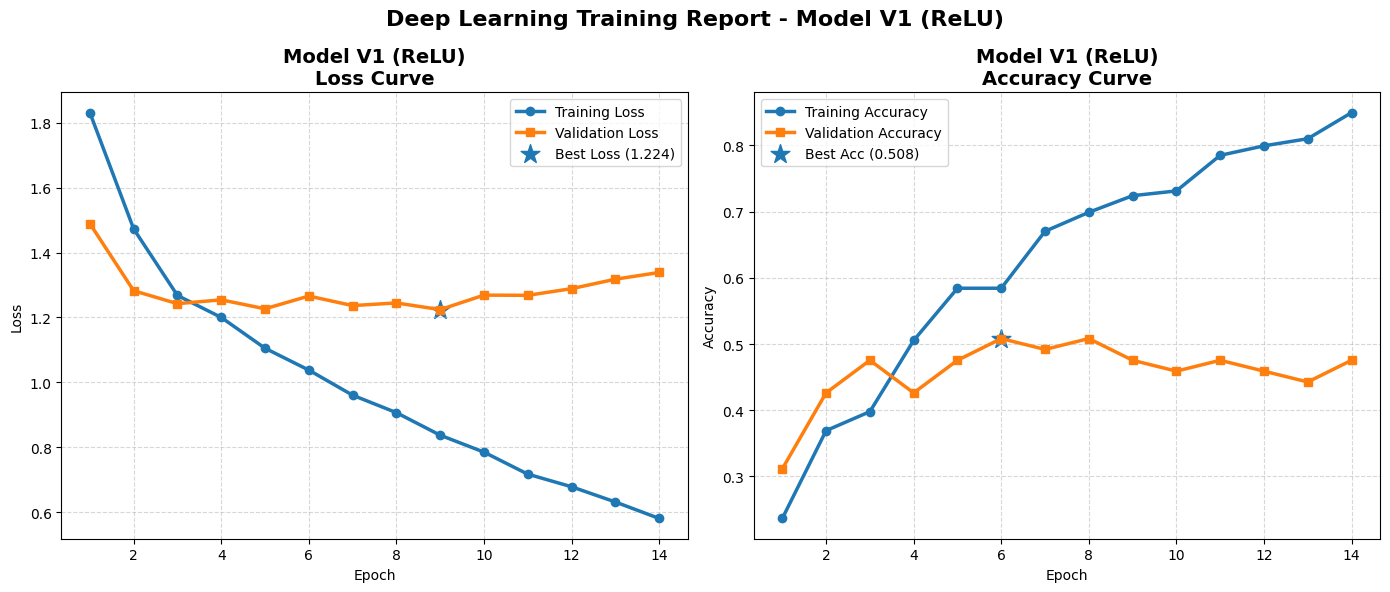


Model V1 (ReLU)
Best Validation Accuracy : 0.5082
Best Validation Loss     : 1.2242
Best Accuracy Epoch      : 6
Best Loss Epoch          : 9


<Figure size 640x480 with 0 Axes>

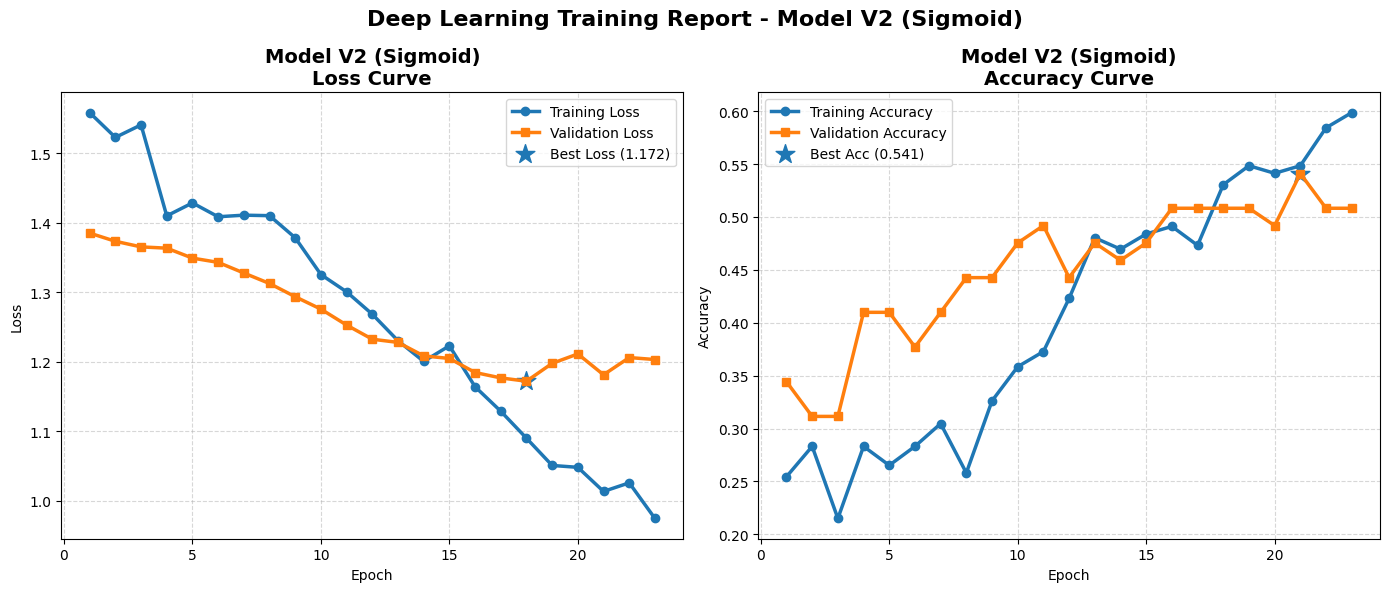


Model V2 (Sigmoid)
Best Validation Accuracy : 0.5410
Best Validation Loss     : 1.1721
Best Accuracy Epoch      : 21
Best Loss Epoch          : 18


<Figure size 640x480 with 0 Axes>

In [12]:
def plot_learning_curves(history, title, filename):

    train_loss = history.history['loss']
    val_loss = history.history['val_loss']

    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    epochs = np.arange(1, len(train_loss) + 1)

    # Epoch tốt nhất
    best_acc_epoch = np.argmax(val_acc) + 1
    best_loss_epoch = np.argmin(val_loss) + 1

    plt.figure(figsize=(14, 6))

    #  LOSS
    plt.subplot(1, 2, 1)

    plt.plot(
        epochs,
        train_loss,
        marker='o',
        linewidth=2.5,
        label='Training Loss'
    )

    plt.plot(
        epochs,
        val_loss,
        marker='s',
        linewidth=2.5,
        label='Validation Loss'
    )

    plt.scatter(
        best_loss_epoch,
        val_loss[best_loss_epoch-1],
        s=200,
        marker='*',
        label=f'Best Loss ({val_loss[best_loss_epoch-1]:.3f})'
    )

    plt.title(
        f'{title}\nLoss Curve',
        fontsize=14,
        fontweight='bold'
    )

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    #  ACCURACY 
    plt.subplot(1, 2, 2)

    plt.plot(
        epochs,
        train_acc,
        marker='o',
        linewidth=2.5,
        label='Training Accuracy'
    )

    plt.plot(
        epochs,
        val_acc,
        marker='s',
        linewidth=2.5,
        label='Validation Accuracy'
    )

    plt.scatter(
        best_acc_epoch,
        val_acc[best_acc_epoch-1],
        s=200,
        marker='*',
        label=f'Best Acc ({val_acc[best_acc_epoch-1]:.3f})'
    )

    plt.title(
        f'{title}\nAccuracy Curve',
        fontsize=14,
        fontweight='bold'
    )

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    plt.suptitle(
        f'Deep Learning Training Report - {title}',
        fontsize=16,
        fontweight='bold'
    )

    plt.tight_layout()

    plt.savefig(
        f"data/{filename}",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    print("\n" + "="*60)
    print(f"{title}")
    print("="*60)
    print(f"Best Validation Accuracy : {max(val_acc):.4f}")
    print(f"Best Validation Loss     : {min(val_loss):.4f}")
    print(f"Best Accuracy Epoch      : {best_acc_epoch}")
    print(f"Best Loss Epoch          : {best_loss_epoch}")
    
    plt.tight_layout()
    plt.savefig(f"data/{filename}", dpi=120)
    plt.show()

# Thực hiện vẽ và lưu biểu đồ cho cả 2 model
plot_learning_curves(history_v1, "Model V1 (ReLU)", "learning_curve_v1.png")
plot_learning_curves(history_v2, "Model V2 (Sigmoid)", "learning_curve_v2.png")


 ĐÁNH GIÁ MÔ HÌNH: Model V1 ReLU 

              precision    recall  f1-score   support

         Bus       0.20      0.07      0.10        15
         Car       0.33      0.33      0.33        15
       Truck       0.35      0.73      0.48        15
  motorcycle       0.33      0.20      0.25        15

    accuracy                           0.33        60
   macro avg       0.31      0.33      0.29        60
weighted avg       0.31      0.33      0.29        60



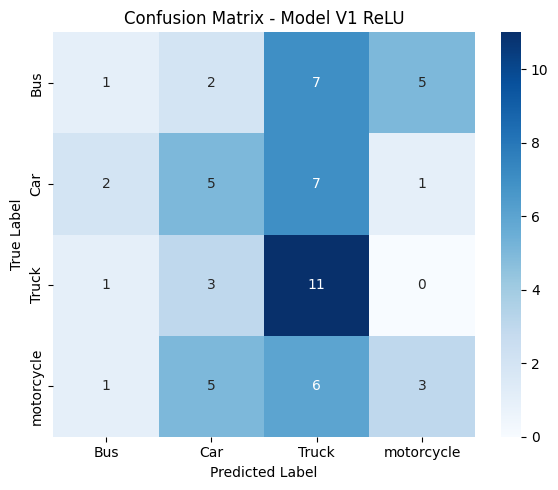


 ĐÁNH GIÁ MÔ HÌNH: Model V2 Sigmoid 

              precision    recall  f1-score   support

         Bus       0.38      0.40      0.39        15
         Car       0.44      0.47      0.45        15
       Truck       0.47      0.47      0.47        15
  motorcycle       0.46      0.40      0.43        15

    accuracy                           0.43        60
   macro avg       0.44      0.43      0.43        60
weighted avg       0.44      0.43      0.43        60



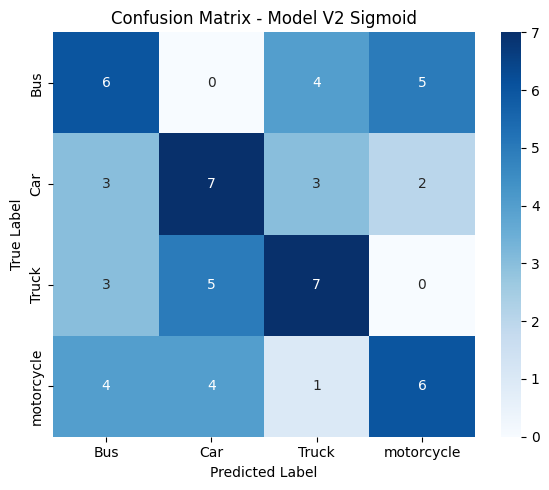

In [11]:
def evaluate_model(model, title):
    print(f"\n ĐÁNH GIÁ MÔ HÌNH: {title} \n")

    # Dự đoán trên tập Test
    predictions = model.predict(X_test, verbose=0)

    # Chuyển xác suất thành nhãn dự đoán
    y_pred = np.argmax(predictions, axis=1)

    # y_test đã là nhãn số nên KHÔNG dùng argmax
    y_true = y_test

    # In Classification Report
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names
    ))

    # Tạo Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Vẽ Confusion Matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()

    # Lưu hình
    plt.savefig(
        f"data/confusion_matrix_{title.lower().replace(' ', '_')}.png",
        dpi=120
    )

    plt.show()


# Đánh giá hai mô hình
evaluate_model(model_v1, "Model V1 ReLU")
evaluate_model(model_v2, "Model V2 Sigmoid")